# Host-specific or just common words? (K2)

**Artifact:** `art_8qkrjl1oVzKi` (evaluation, iteration 5). **Label:** *POST-CONFIRMATION EXPLORATORY*. Every fold was opened in earlier iterations, so nothing here is a new confirmation.

**Background.** When a scientific concept `c` enters a new host subfield `d` in year `e`, some of its partner keywords already have a high *host share*: a large fraction of their pre-entry literature sits in `d`. The confirmed D2 result is that a higher mean host share, **`A_cont`**, predicts more uptake of `c` in `d` by newcomer authors (outcome `Y_strict`, PPML with concept + e + d fixed effects). The IRR per SD is 1.30 on the screen fold, 1.19 on the held-out fold and 1.23 on the MeSH replication.

**The question.** Is that effect *host-specific*, or is it *generic accessibility*? Under the rival reading, host-leaning partners are simply widely used, frequent words that make any paper findable. K2 adds two standard term-generality proxies of the partners, both measured on exact pre-entry OpenAlex subfield × 5-year-block profiles:

- **`G_H`**: the tag-weighted mean *normalised Shannon entropy* of each partner's subfield profile (how dispersed the partner is);
- **`G_F`**: the tag-weighted mean *log block frequency* (how common the partner is).

K2 also replaces `A_cont` by its activity-index form, **`A_lift` = ln(A_cont / s_dB)**, where `s_dB` is the host's share of all works in the block.

**Models (per fold, PPML, FE concept + e + d, offset log n_entry_papers, CRV1 by concept):**

| model | focal | regressors |
|---|---|---|
| M0 | `A_cont` | `A_cont` + CT + controls |
| M1 | `A_cont` | `A_cont` + `G_H` + `G_F` + CT + controls |
| M2 | `A_lift` | `A_lift` + CT + controls |
| M3 | `A_lift` | `A_lift` + `G_H` + `G_F` + CT + controls |

**Frozen decision rule.** Retention `ret = b_A(M1) / b_A(M0)` is the share of the effect that survives the generality controls. **GENERIC ACCESSIBILITY** if `ret < 0.5`. **HOST-SPECIFIC** if the M3 `A_lift` CI lies entirely above 1 *and* `ret ≥ 0.5`. **MIXED** otherwise. The pooled (IVW over the three folds) verdict is the reading.

**What the original run did.** `k2_prepare` → `k2_features` (gates, partner measures) → `k2_freeze` (spec sha256 `866c60a8…`) → `k2_power` (design analysis) → `k2_run` (fits, p-values, bootstrap, IVW, verdict, supplementary rows) → `k2_placebo` (S10) → `k2_s2b` → `audit_k2` → `eval.py` (figures).

**What this notebook runs.** Building the partner profiles needs the 208k-work OpenAlex corpus and the MeSH works, so the notebook starts from the stored **K2 input samples**: every one of the 5,086 concept-entry events, with the partner measures already computed. From there it re-runs, with the original code:

1. the reproduction gates;
2. the within-FE descriptives;
3. the Step-3 retention design analysis;
4. the M0–M3 fits with CRV1, wild, placebo-calibrated and Freedman–Lane randomisation p-values;
5. the concept-cluster bootstrap for the retention CI;
6. IVW pooling and the frozen verdict;
7. the supplementary rows S2–S8;
8. figures F1–F3.

Point estimates are therefore **identical** to the full run. Only the number of resampling draws is reduced (see the configuration cell). S10, S2b and the audit need partner-level tag arrays from the corpus, so their full-run results are loaded and shown instead.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru: NOT pre-installed on Colab, always install
_pip('loguru==0.7.3')

# numpy, pandas, scipy, matplotlib: pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'matplotlib==3.10.0')

## Imports

These are the imports of `k2/k2_lib.py`, `k2/k2_run.py`, `d2/src/ppml.py`, `d2/src/models.py` and `eval.py`. The originals log to stdout and to `logs/*.log`; the notebook keeps only the stdout sink.

In [2]:
import os
for _v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS"):
    os.environ.setdefault(_v, "1")  # as k2_lib.py: single-threaded BLAS (the small dense solves gain nothing from threads)

import json
import sys
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from loguru import logger
from scipy import stats

import matplotlib
import matplotlib.pyplot as plt

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
warnings.filterwarnings("ignore")  # as the original workers (_init: warnings.filterwarnings("ignore"))

## Data loading

The loader tries the GitHub copy of `mini_demo_data.json` first and falls back to a local file.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8892b7-occupancy-is-not-integration-for-new/main/round-5/evaluation-7/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
DATA = load_data()
META, REF = DATA["metadata"], DATA["full_run_reference"]
print(META["description"])
for f, d in DATA["folds"].items():
    print(f"  {f:8s}: {d['n_events']:5d} events, {d['n_concepts']} concepts")
print("label:", META["label"], "| frozen spec sha256:", META["spec_sha256"][:8])

K2 input samples of the three folds (screen, held-out, MeSH): one row per concept-entry event (concept c enters host subfield d in year e) with the outcome Y_strict, the host-share A_cont, the co-primary controls and the partner-generality proxies G_H / G_F. All events of every fold are included (no subsampling).
  screen  :  1740 events, 184 concepts
  heldout :  1097 events, 93 concepts
  mesh    :  2249 events, 187 concepts
label: POST-CONFIRMATION EXPLORATORY | frozen spec sha256: 866c60a8


## Configuration

All tunable parameters. The point estimates, gates, descriptives and verdict do not depend on them. They only set the number of resampling draws behind the bootstrap CIs and the randomisation / design-analysis probabilities. The demo values keep the whole notebook within a few minutes on a 2-core Colab CPU. Set them to the original values to reproduce the full run's draw counts (about 30 minutes on one core).

| parameter | what it controls | demo | original |
|---|---|---|---|
| `B_BOOT` | concept-cluster bootstrap draws per fold (retention CI) | 200 | 1000 |
| `R_PERM` | Freedman–Lane within-concept randomisation draws per fold × model | 100 | 2000 |
| `WILD_REPS` | Rademacher wild cluster score-bootstrap reps per focal term | 999 | 999 |
| `POWER_REPS` | Step-3 design-analysis reps per fold × DGP | 50 | 300 |

In [5]:
B_BOOT = 200       # original 1000
R_PERM = 100       # original 2000
WILD_REPS = 999    # original 999
POWER_REPS = 50    # original 300

## Estimator: PPML with high-dimensional fixed effects (`d2/src/ppml.py`, verbatim)

This is the vendored exp_7 estimator, byte-identical to its source in the original run (60/60 vendored files hash-matched). It fits Poisson pseudo-maximum likelihood by IRLS. Fixed effects are absorbed by an exact weighted projection with a sparse LU solve. Singleton and all-zero FE levels are pruned iteratively. The standard errors are CRV1, clustered by concept, with pyfixest's small-sample factor. `wild_score_test` is the Kline–Santos wild cluster score bootstrap.

In [6]:
def _prune(y: np.ndarray, fes: list[np.ndarray]) -> np.ndarray:
    """Iteratively drop singleton FE levels and FE levels with all-zero outcome (separation)."""
    keep = np.ones(len(y), bool)
    for _ in range(50):
        changed = False
        for f in fes:
            cnt = np.bincount(f[keep], minlength=f.max() + 1)
            sy = np.bincount(f[keep], weights=y[keep], minlength=f.max() + 1)
            bad = (cnt <= 1) | (sy <= 0)
            drop = keep & bad[f]
            if drop.any():
                keep &= ~drop
                changed = True
        if not changed:
            break
    return keep


def _demean(M: np.ndarray, w: np.ndarray, fes: list[np.ndarray]) -> np.ndarray:
    """Exact weighted projection off the FE space: solve (D'WD + eps I) c = D'W M with a sparse LU (D = [D1 D2])."""
    from scipy import sparse
    from scipy.sparse.linalg import splu
    n = len(w)
    rows, cols, off = [], [], 0
    for f in fes:
        rows.append(np.arange(n))
        cols.append(f + off)
        off += int(f.max()) + 1
    D = sparse.csc_matrix((np.ones(n * len(fes)), (np.concatenate(rows), np.concatenate(cols))), shape=(n, off))
    DW = sparse.csc_matrix(D.multiply(w[:, None]))
    A = sparse.csc_matrix(D.T @ DW) + sparse.identity(off, format="csc") * 1e-9
    c = splu(A).solve(np.asarray(DW.T @ M))
    return M - D @ c


def pd_nunique_per_level(f: np.ndarray, g: np.ndarray) -> int:
    """Max number of distinct clusters within any FE level."""
    pairs = np.unique(np.stack([f, g], 1), axis=0)
    return int(np.bincount(pairs[:, 0]).max())


def fit(y: np.ndarray, X: np.ndarray, fes: list[np.ndarray], offset: np.ndarray, cluster: np.ndarray,
        maxit: int = 100, tol: float = 1e-9) -> dict | None:
    keep = _prune(y.astype(float), fes)
    if keep.sum() < X.shape[1] + 5:
        return None
    y, X, off, cl = y[keep].astype(float), X[keep], offset[keep], cluster[keep]
    fes = [np.unique(f[keep], return_inverse=True)[1] for f in fes]
    if np.linalg.matrix_rank(_demean(X, np.ones(len(y)), fes)) < X.shape[1]:
        return None
    mu = np.maximum(y, 0.1 * y.mean() + 1e-3)
    eta = np.log(mu)
    beta = np.zeros(X.shape[1])
    dev_old = np.inf
    for _ in range(maxit):
        z = eta - off + (y - mu) / mu
        M = _demean(np.column_stack([z, X]), mu, fes)
        zt, Xt = M[:, 0], M[:, 1:]
        WX = Xt * mu[:, None]
        beta = np.linalg.solve(Xt.T @ WX, WX.T @ zt)
        resid = zt - Xt @ beta
        eta = z - resid + off  # eta = X b + FE + offset
        eta = np.clip(eta, -30, 30)
        mu = np.exp(eta)
        dev = 2 * np.sum(np.where(y > 0, y * np.log(np.where(y > 0, y, 1) / mu), 0) - (y - mu))
        if abs(dev - dev_old) / (abs(dev) + 0.1) < tol:
            break
        dev_old = dev
    Xt = _demean(X, mu, fes)
    H = Xt.T @ (Xt * mu[:, None])
    Hi = np.linalg.inv(H)
    sc = Xt * (y - mu)[:, None]
    _, g = np.unique(cl, return_inverse=True)
    G = g.max() + 1
    S = np.zeros((G, X.shape[1]))
    np.add.at(S, g, sc)
    n = len(y)
    # small-sample factor as pyfixest CRV1 (fixef_k='nested'): FE levels nested in clusters are not counted
    k_fe = 0
    for f in fes:
        nested = np.all(np.bincount(f, minlength=f.max() + 1) == 0) or (
            pd_nunique_per_level(f, g) <= 1)
        if not nested:
            k_fe += int(f.max()) + 1 - 1
    k = X.shape[1] + k_fe + (1 if k_fe else 0)
    adj = G / (G - 1) * (n - 1) / (n - k) if G > 1 and n > k else 1.0
    V = adj * Hi @ (S.T @ S) @ Hi
    return {"coef": beta, "se": np.sqrt(np.diag(V)), "n": int(n), "G": int(G), "mu": mu, "keep": keep,
            "Xt": Xt, "y": y, "cl": g}


def wild_score_test(y, X_restricted, x2, fes, offset, cluster, rng, reps: int = 199) -> float | None:
    """Kline-Santos wild cluster (Rademacher) score bootstrap for H0: coefficient on x2 = 0."""
    r = fit(y, X_restricted, fes, offset, cluster)
    if r is None:
        return None
    keep, mu = r["keep"], r["mu"]
    fes_k = [np.unique(f[keep], return_inverse=True)[1] for f in fes]
    Xall = np.column_stack([x2[keep], X_restricted[keep]])
    D = _demean(Xall, mu, fes_k)
    x2t, Xrt = D[:, 0], D[:, 1:]
    b = np.linalg.solve(Xrt.T @ (Xrt * mu[:, None]), (Xrt * mu[:, None]).T @ x2t)
    x2r = x2t - Xrt @ b
    s = np.bincount(r["cl"], weights=x2r * (r["y"] - mu))
    if len(s) < 2 or (s ** 2).sum() == 0:
        return None
    T = s.sum() ** 2 / (s ** 2).sum()
    eps = rng.choice([-1.0, 1.0], size=(reps, len(s)))
    Ts = (eps @ s) ** 2 / (s ** 2).sum()
    return float((1 + (Ts >= T).sum()) / (reps + 1))


from types import SimpleNamespace
ppml = SimpleNamespace(fit=fit, _demean=_demean, wild_score_test=wild_score_test)  # DEMO: module namespace stand-in

## Model wrapper (`d2/src/models.py`, the parts K2 uses)

`fit_one` turns a raw PPML fit into the reporting set: coefficient, CRV1 SE, t(G−1) p-value, **IRR per SD** of the regressor on the retained sample with its CI, and optionally the wild p-value. `holm` is the Holm adjustment. The control list is the co-primary one, 3 regressors plus 8 event controls plus 3 secondary extras. The code is verbatim, except that the wild-bootstrap reps (999 in the original) are read from `WILD_REPS`.

In [7]:
SEED = 20261001  # K2 seed (k2_lib.SEED); models.py's own SEED is only a default for rng
EVENT_CONTROLS = ["prox_od", "RD", "log_n_partner_tags", "cov", "demic", "mean_topic_score", "boundary_share",
                  "abstract_share"]
SECONDARY_EXTRA = ["mom_d", "log_centrality", "log_W1"]
FE_SPECS = {"primary": ["cxe", "dxe"], "secondary": ["cfe", "efe", "dfe"],
            "coarse_cx2y": ["cx2", "dxe"],  # pre-declared coarsening: concept x 2-year entry bin + d x e
            "c_plus_dxe": ["cfe", "dxe"]}   # pre-declared alternative: concept + d x e


def fe_arrays(s: pd.DataFrame, spec: str) -> list[np.ndarray]:
    return [s[c].to_numpy() for c in FE_SPECS[spec]]


def fit_one(s: pd.DataFrame, y: str, xvars: list[str], spec: str = "primary", wild: bool = False,
            wild_vars: tuple = (), rng=None) -> dict | None:
    X = s[xvars].to_numpy(float)
    fes = fe_arrays(s, spec)
    yv = s[y].to_numpy(float)
    r = ppml.fit(yv, X, fes, s.offset.to_numpy(), s.concept_id.to_numpy(), maxit=500, tol=1e-12)
    if r is None:
        return None
    keep = r["keep"]
    G = r["G"]
    out = {"spec": spec, "y": y, "x": xvars, "n_input": int(len(s)), "n_retained": int(r["n"]), "G": int(G),
           "retained_share": float(r["n"] / len(s)), "coef": {}, "se": {}, "p": {}, "irr_sd": {}, "irr_01": {},
           "ci_irr_sd": {}, "sd_retained": {}}
    # singleton / separation accounting for the first FE dimension
    cells = pd.Series(fes[0]).value_counts()
    out["n_nonsingleton_fe0_cells"] = int((cells >= 2).sum())
    out["n_fe0_cells"] = int(len(cells))
    out["events_in_nonsingleton_fe0_cells"] = int(cells[cells >= 2].sum())
    tq = stats.t.ppf(0.975, G - 1)
    for i, v in enumerate(xvars):
        b, se = float(r["coef"][i]), float(r["se"][i])
        sd = float(s.loc[keep, v].std())
        tstat = b / se if se > 0 else np.nan
        out["coef"][v], out["se"][v] = b, se
        out["p"][v] = float(2 * stats.t.sf(abs(tstat), G - 1)) if se > 0 else np.nan
        out["sd_retained"][v] = sd
        out["irr_sd"][v] = float(np.exp(b * sd))
        out["irr_01"][v] = float(np.exp(b * 0.1))
        out["ci_irr_sd"][v] = [float(np.exp((b - tq * se) * sd)), float(np.exp((b + tq * se) * sd))]
    out["deviance"] = float(2 * np.sum(np.where(r["y"] > 0, r["y"] * np.log(np.where(r["y"] > 0, r["y"], 1) / r["mu"]),
                                                 0) - (r["y"] - r["mu"])))
    if wild:
        rng = rng or np.random.default_rng(SEED)
        out["p_wild"] = {}
        for v in wild_vars:
            j = xvars.index(v)
            Xr = np.delete(X, j, axis=1)
            out["p_wild"][v] = ppml.wild_score_test(yv, Xr, X[:, j], fes, s.offset.to_numpy(), s.concept_id.to_numpy(),
                                                    rng, reps=WILD_REPS)  # DEMO: reps=999 in the original
    return out


def holm(pvals: dict) -> dict:
    items = sorted(pvals.items(), key=lambda kv: kv[1])
    m = len(items)
    adj, run = {}, 0.0
    for i, (k, p) in enumerate(items):
        run = max(run, min(1.0, (m - i) * p))
        adj[k] = run
    return adj


models = SimpleNamespace(fit_one=fit_one, fe_arrays=fe_arrays, holm=holm,  # DEMO: module namespace stand-in
                         EVENT_CONTROLS=EVENT_CONTROLS, SECONDARY_EXTRA=SECONDARY_EXTRA)

## K2 library (`k2/k2_lib.py`, the analysis part)

This section holds the model definitions M0–M3, the fold-sample helpers, `A_lift`, the within-FE algebra, the fit wrappers, IVW pooling and the resampling workers. It is copied from `k2_lib.py` and `g/g_lib.py`, with three changes:

- `placebo_zsd` reads the stored SD of the recorded no-generality placebo z-scores.
- `source_paths` is dropped.
- `pool`, originally a `ProcessPoolExecutor` with the spawn start method, runs the same worker functions serially in the notebook. Every draw has its own seed, so results do not depend on the number of workers.

In [8]:
FOLDS = ("screen", "heldout", "mesh")
CTRL = models.EVENT_CONTROLS + models.SECONDARY_EXTRA  # co-primary controls (identical list in mesh_spec)
NAT_CUT, ADJ_LO = 0.30, 0.05  # g_spec G2 class cuts

MODELS = {  # focal term first
    "M0": ["A_cont"],
    "M1": ["A_cont", "G_H", "G_F"],
    "M2": ["A_lift"],
    "M3": ["A_lift", "G_H", "G_F"],
}
FOCAL = {"M0": "A_cont", "M1": "A_cont", "M2": "A_lift", "M3": "A_lift"}


def clean(o):
    """Recursively replace NaN/inf by None for JSON."""
    if isinstance(o, dict):
        return {k: clean(v) for k, v in o.items()}
    if isinstance(o, (list, tuple)):
        return [clean(v) for v in o]
    if isinstance(o, (float, np.floating)):
        return float(o) if np.isfinite(o) else None
    if isinstance(o, np.integer):
        return int(o)
    if isinstance(o, np.bool_):
        return bool(o)
    return o


def refac(s: pd.DataFrame) -> pd.DataFrame:
    s = s.reset_index(drop=True).copy()
    for c, key in (("cxe", s.concept_id + "_" + s.e.astype(str)), ("dxe", s.d.astype(str) + "_" + s.e.astype(str)),
                   ("cfe", s.concept_id), ("efe", s.e.astype(str)), ("dfe", s.d.astype(str))):
        s[c] = pd.factorize(key)[0]
    s["offset"] = np.log(s.n_entry_papers.astype(float))
    return s


def add_lift(k: pd.DataFrame) -> dict:
    """A_lift = ln((A_cont + c0) / s_dB); c0 = 0.5 x smallest positive A_cont in the fold, used only if any A == 0."""
    a = k.A_cont.to_numpy(float)
    nz = int((a == 0).sum())
    c0 = 0.5 * float(a[a > 0].min()) if nz else 0.0
    k["A_lift"] = np.log((a + c0) / k.s_dB.to_numpy(float))
    k["ln_A_cont"] = np.log(a + c0)
    k["ln_s_dB"] = np.log(k.s_dB.to_numpy(float))
    k["zeroA"] = a == 0
    return {"n_zero_A": nz, "c0": c0}


# ------------------------------------------------------------------------------------------------ within-FE algebra
def within(s: pd.DataFrame, cols: list[str], fe=("cfe", "efe", "dfe")) -> np.ndarray:
    """Unweighted within-FE residuals (alternating projections) of the columns."""
    fes = [pd.factorize(s[c])[0] for c in fe]
    return ppml._demean(s[cols].to_numpy(float), np.ones(len(s)), fes)


def within_r2(s: pd.DataFrame, y: str, xs: list[str]) -> float:
    M = within(s, [y] + xs)
    yt, Xt = M[:, 0], M[:, 1:]
    b, *_ = np.linalg.lstsq(Xt, yt, rcond=None)
    r = yt - Xt @ b
    return float(1 - (r ** 2).sum() / (yt ** 2).sum())


def within_proj(s: pd.DataFrame, y: str, xs: list[str]) -> tuple[np.ndarray, np.ndarray, float]:
    """Linear projection of y on xs + FE: returns (fitted incl. FE part, residual, within R2)."""
    M = within(s, [y] + xs)
    yt, Xt = M[:, 0], M[:, 1:]
    b, *_ = np.linalg.lstsq(Xt, yt, rcond=None)
    res = yt - Xt @ b
    fitted = s[y].to_numpy(float) - res
    return fitted, res, float(1 - (res ** 2).sum() / (yt ** 2).sum())


# ------------------------------------------------------------------------------------------------ fits
def xvars_of(model: str, extra_first: list[str] | None = None) -> list[str]:
    return (extra_first or MODELS[model]) + ["CT"] + CTRL


def fit_b(s: pd.DataFrame, xs: list[str], spec: str = "secondary", y: str = "Y_strict") -> dict | None:
    """Raw PPML fit -> {'coef','se','G','n'} (no reporting overhead)."""
    try:
        r = ppml.fit(s[y].to_numpy(float), s[xs].to_numpy(float), models.fe_arrays(s, spec), s.offset.to_numpy(),
                     s.concept_id.to_numpy(), maxit=500, tol=1e-12)
    except (np.linalg.LinAlgError, ValueError, RuntimeError, FloatingPointError):
        return None
    return r


def fit_rows(s: pd.DataFrame, xs: list[str], targets: list[str], *, fold: str, model: str, spec: str = "secondary",
             label: str, y: str = "Y_strict", wild: tuple = (), zsd: float | None = None, rng=None,
             extra: dict | None = None) -> tuple[list[dict], dict | None]:
    base = {"fold": fold, "model": model, "spec": spec, "y": y, "label": label, **(extra or {})}  # DEMO: no 'source'
    try:
        r = models.fit_one(s, y, xs, spec, wild=bool(wild), wild_vars=tuple(wild),
                           rng=rng or np.random.default_rng(SEED))
    except (np.linalg.LinAlgError, ValueError, RuntimeError) as ex:
        logger.warning(f"{fold}/{model}: fit failed {ex!r}")
        r = None
    if r is None:
        return [{**base, "var": t, "note": "fit failed / too few observations", "N_input": int(len(s))}
                for t in targets], None
    rows = []
    tq = stats.t.ppf(0.975, r["G"] - 1)
    for t in targets:
        b, se = r["coef"][t], r["se"][t]
        z = b / se if se > 0 else np.nan
        rows.append({**base, "var": t, "b": b, "se": se, "z": z, "p_crv1": r["p"][t], "irr_sd": r["irr_sd"][t],
                     "irr_sd_lo": r["ci_irr_sd"][t][0], "irr_sd_hi": r["ci_irr_sd"][t][1], "irr_01": r["irr_01"][t],
                     "sd_retained": r["sd_retained"][t], "lnirr_sd": b * r["sd_retained"][t],
                     "lnirr_sd_se": se * r["sd_retained"][t], "tq": tq,
                     "p_wild": (r.get("p_wild") or {}).get(t),
                     "p_placebo_cal": float(2 * stats.norm.sf(abs(z) / zsd)) if zsd and np.isfinite(z) else None,
                     "N_input": r["n_input"], "N": r["n_retained"], "G": r["G"],
                     "retained_share": r["retained_share"]})
    return rows, r


def placebo_zsd(fold: str) -> float:
    # DEMO: the original reads placebo_draws.csv (z_A_secondary) / placebo_draws_mesh.csv (z_A_R2) and takes the SD;
    # the demo file stores that SD.
    return float(DATA["folds"][fold]["placebo_z_sd"])


def ivw(b: np.ndarray, se: np.ndarray) -> dict:
    b, se = np.asarray(b, float), np.asarray(se, float)
    ok = np.isfinite(b) & np.isfinite(se) & (se > 0)
    b, se = b[ok], se[ok]
    w = 1 / se ** 2
    bp = float((w * b).sum() / w.sum())
    sp = float(np.sqrt(1 / w.sum()))
    Q = float((w * (b - bp) ** 2).sum())
    k = len(b)
    I2 = float(max(0.0, (Q - (k - 1)) / Q)) if Q > 0 and k > 1 else 0.0
    return {"b": bp, "se": sp, "lo": bp - 1.959963984540054 * sp, "hi": bp + 1.959963984540054 * sp,
            "z": bp / sp, "p": float(2 * stats.norm.sf(abs(bp / sp))), "Q": Q, "df": k - 1,
            "p_Q": float(stats.chi2.sf(Q, k - 1)) if k > 1 else None, "I2": I2, "k": k,
            "weights": (w / w.sum()).tolist()}


# ------------------------------------------------------------------------------------------------ workers
_W: dict = {}


def resample_concepts(s: pd.DataFrame, rng, n_conc: int | None = None) -> pd.DataFrame:  # g/g_lib.py
    cids = s.concept_id.unique()
    pick = rng.choice(cids, n_conc or len(cids))
    g = {c: x for c, x in s.groupby("concept_id")}
    parts = []
    for i, c in enumerate(pick):
        x = g[c].copy()
        x["concept_id"] = f"{c}#{i}"
        parts.append(x)
    b = pd.concat(parts, ignore_index=True)
    for c, key in (("cxe", b.concept_id + "_" + b.e.astype(str)), ("dxe", b.d.astype(str) + "_" + b.e.astype(str)),
                   ("cfe", b.concept_id), ("efe", b.e.astype(str)), ("dfe", b.d.astype(str))):
        b[c] = pd.factorize(key)[0]
    return b


def resample(s: pd.DataFrame, rng) -> pd.DataFrame:
    return resample_concepts(s, rng)


def _boot_task(args) -> dict:
    """One concept-cluster bootstrap draw: target coefficients of every (name, xs, targets, spec) fit on the
    resampled fold sample."""
    fold, seed = args
    s = _W["samples"][fold]
    b = resample(s, np.random.default_rng(seed))
    out = {"fold": fold, "seed": seed}
    for name, xs, targets, spec in _W["pairs"][fold]:
        r = fit_b(b, xs, spec)
        for t in targets:
            out[f"{name}|{t}"] = None if r is None else float(r["coef"][xs.index(t)])
    return out


def _perm_task(args) -> dict:
    """Freedman-Lane within-concept permutation draw for one (fold, model): permute the linear residual of the
    focal regressor (on the other regressors + FE) within concept, add back the fitted part, refit the PPML."""
    fold, model, seed = args
    s = _W["samples"][fold]
    fl = _W["fl"][(fold, model)]
    rng = np.random.default_rng(seed)
    res = fl["res"].copy()
    for ix in fl["groups"]:
        res[ix] = res[ix][rng.permutation(len(ix))]
    xs = fl["xs"]
    X = s[xs].to_numpy(float).copy()
    X[:, 0] = fl["fitted"] + res
    try:
        r = ppml.fit(s.Y_strict.to_numpy(float), X, models.fe_arrays(s, "secondary"), s.offset.to_numpy(),
                     s.concept_id.to_numpy(), maxit=500, tol=1e-12)
    except (np.linalg.LinAlgError, ValueError, RuntimeError, FloatingPointError):
        r = None
    if r is None:
        return {"fold": fold, "model": model, "seed": seed, "z": None}
    return {"fold": fold, "model": model, "seed": seed, "z": float(r["coef"][0] / r["se"][0])}


def fl_prep(s: pd.DataFrame, xs: list[str]) -> dict:
    fitted, res, r2 = within_proj(s, xs[0], xs[1:])
    groups = list(s.groupby("cfe").indices.values())
    return {"fitted": fitted, "res": res, "groups": groups, "xs": xs, "r2_focal_on_rest": r2}


def pool(payload: dict, fn, tasks: list, chunksize: int = 4) -> list:
    # DEMO: the original maps fn over tasks in a spawn ProcessPoolExecutor (workers get `payload` via _init);
    # in the notebook the same worker functions run serially.
    _W.clear()
    _W.update(payload)
    return [fn(t) for t in tasks]

## Step 0: K2 input samples and reproduction gates (`k2/k2_features.py`)

Each fold's K2 input sample is the co-primary D2 sample joined with the entry-level partner measures. `A_lift` is then added, events without profiled generality are dropped, and fresh FE ids are built. The demo file already holds the joined rows, so the notebook only repeats the last three steps.

- **GATE-A:** `A_cont` rebuilt from the partner tags equals the stored column. The rebuilt column was computed from the corpus tags in the original run and is stored in the file.
- **GATE-B:** refitting the recorded co-primary model (`A_cont` + CT + controls, FE concept + e + d) reproduces the recorded IRR/SD, N and G.

In [9]:
samples, lift_info, gates = {}, {}, {}
for f in FOLDS:
    k = pd.DataFrame(DATA["folds"][f]["columns"])
    k["fold"] = f
    lift_info[f] = add_lift(k)
    s = refac(k.dropna(subset=["G_H", "G_F", "A_lift"]))
    samples[f] = s
    ga = float(np.nanmax(np.abs(s.A_cont_rebuilt - s.A_cont)))
    rec = DATA["folds"][f]["recorded_coprimary"]
    r = models.fit_one(s, "Y_strict", ["A_cont", "CT"] + CTRL, "secondary")
    d_ln = abs(np.log(r["irr_sd"]["A_cont"]) - np.log(rec["irr_sd"]))
    ok = ga <= 1e-9 and d_ln < 1e-6 and r["n_retained"] == rec["N"] and r["G"] == rec["G"]
    gates[f] = "PASS" if ok else "FAIL"
    logger.info(f"[{f}] input {len(s)} events / {s.concept_id.nunique()} concepts; zero-A {lift_info[f]['n_zero_A']} "
                f"(c0 {lift_info[f]['c0']:.2e}); GATE-A max|diff| {ga:.1e}; GATE-B IRR/SD {r['irr_sd']['A_cont']:.4f} "
                f"vs recorded {rec['irr_sd']:.4f} (|d ln| {d_ln:.1e}), N {r['n_retained']}/{rec['N']}, "
                f"G {r['G']}/{rec['G']} -> {gates[f]}")

13:03:22|INFO   |[screen] input 1740 events / 184 concepts; zero-A 0 (c0 0.00e+00); GATE-A max|diff| 1.1e-16; GATE-B IRR/SD 1.3001 vs recorded 1.3001 (|d ln| 8.9e-16), N 1544/1544, G 140/140 -> PASS


13:03:22|INFO   |[heldout] input 1097 events / 93 concepts; zero-A 1 (c0 8.11e-06); GATE-A max|diff| 1.0e-15; GATE-B IRR/SD 1.1875 vs recorded 1.1875 (|d ln| 7.5e-16), N 972/972, G 74/74 -> PASS


13:03:22|INFO   |[mesh] input 2249 events / 187 concepts; zero-A 0 (c0 0.00e+00); GATE-A max|diff| 1.0e-15; GATE-B IRR/SD 1.2330 vs recorded 1.2330 (|d ln| 5.6e-16), N 2171/2171, G 160/160 -> PASS


### Outcome-free descriptives

The generic-accessibility story needs host share and generality to move together. Here they are compared *within* the fixed effects, which is the variation the models use. The cell also checks how much of `A_lift` is anything other than `ln A_cont`.

In [10]:
desc = {}
for f in FOLDS:
    k = samples[f]
    M = within(k, ["A_cont", "G_H", "G_F", "A_lift", "ln_A_cont", "ln_s_dB"])
    C = np.corrcoef(M, rowvar=False)
    v = M.var(0)
    desc[f] = {"within_fe_r": {"A_cont~G_H": float(C[0, 1]), "A_cont~G_F": float(C[0, 2]), "G_H~G_F": float(C[1, 2]),
                               "A_lift~ln_A_cont": float(C[3, 4]), "A_lift~ln_s_dB": float(C[3, 5])},
               "within_fe_R2_A_cont_on_G": within_r2(k, "A_cont", ["G_H", "G_F"]),
               "share_within_var_A_lift_from_ln_s_dB": float(v[5] / v[3]) if v[3] > 0 else None,
               "partial_residual_trigger_abs_r_gt_0.8": bool(max(abs(C[0, 1]), abs(C[0, 2])) > 0.8)}
tab = pd.DataFrame({f: {"r(A_cont, G_H)": d["within_fe_r"]["A_cont~G_H"], "r(A_cont, G_F)": d["within_fe_r"]["A_cont~G_F"],
                        "R2(A_cont | G)": d["within_fe_R2_A_cont_on_G"],
                        "r(A_lift, ln A_cont)": d["within_fe_r"]["A_lift~ln_A_cont"],
                        "var share of ln s_dB in A_lift": d["share_within_var_A_lift_from_ln_s_dB"]}
                    for f, d in desc.items()}).T
print("Within-FE (concept + e + d) descriptives:")
print(tab.round(3).to_string())

Within-FE (concept + e + d) descriptives:
         r(A_cont, G_H)  r(A_cont, G_F)  R2(A_cont | G)  r(A_lift, ln A_cont)  var share of ln s_dB in A_lift
screen           -0.217          -0.109           0.049                 0.997                           0.007
heldout          -0.163          -0.063           0.029                 0.997                           0.006
mesh             -0.388          -0.248           0.155                 0.999                           0.003


Host share is **negatively** correlated with both generality proxies within FE, and generality explains only 3–16% of its within-FE variance. `A_lift` is almost a monotone transform of `ln A_cont` (r ≈ 0.997), so the `A_lift` leg of the rule carries little independent information. The **retention** leg is the decisive one.

## Step 3: retention design analysis (`k2/k2_power.py`)

Before any K2 coefficient was read, the original run checked that the retention statistic *can* tell the two readings apart. For each fold, the outcome is simulated on the observed design from an NB2 model whose baseline `mu0` comes from a fit with no `A` term:

- **DGP-S (host-specific):** `ln mu = ln mu0 + beta_rec (A_cont − mean)`.
- **DGP-G (generic):** the outcome is driven only by the part of `A_cont` that the generality proxies predict (within-FE projection), scaled so that M0 still recovers `beta_rec`.

Each rep fits M0 and M1 and computes the retention. The code is verbatim from `k2_power.py` (`_rep` and the per-fold setup), run with `POWER_REPS` reps.

In [11]:
def _rep(args) -> dict:
    fold, dgp, seed = args
    P = _W["P"][fold]
    rng = np.random.default_rng(seed)
    mu = P["mu0"] * np.exp(P["lin"][dgp])
    y = rng.poisson(rng.gamma(P["theta"], mu / P["theta"]))
    s = P["base"].copy()
    s["Y_strict"] = y
    out = {"fold": fold, "dgp": dgp, "seed": seed}
    for m in ("M0", "M1"):
        xs = xvars_of(m)
        r = fit_b(s, xs)
        out[f"b_{m}"] = None if r is None else float(r["coef"][0])
        out[f"se_{m}"] = None if r is None else float(r["se"][0])
    return out


t0 = time.time()
P, info = {}, {}
for fold in FOLDS:
    s = samples[fold]
    # DEMO: beta_rec / recorded SE come from gates.json in the original; they are the GATE-B refit, recomputed here
    rb = fit_b(s, ["A_cont", "CT"] + CTRL)
    beta, beta_se = float(rb["coef"][0]), float(rb["se"][0])
    ctrl = ["CT"] + CTRL + ["G_H", "G_F"]
    r0 = fit_b(s, ctrl)
    base = refac(s[r0["keep"]].copy())
    mu0 = r0["mu"]
    yb = base.Y_strict.to_numpy(float)
    theta = float(np.sum(mu0 ** 2) / max(np.sum((yb - mu0) ** 2 - yb), 1e-9))
    theta = theta if theta > 0 else 1e6
    a = base.A_cont.to_numpy(float)
    fitted, res, r2 = within_proj(base, "A_cont", ["G_H", "G_F"])
    M = within(base, ["A_cont", "G_H", "G_F"])
    bproj, *_ = np.linalg.lstsq(M[:, 1:], M[:, 0], rcond=None)
    ahat = base[["G_H", "G_F"]].to_numpy(float) @ bproj
    lin = {"S": beta * (a - a.mean())}
    constructible = r2 >= 0.02
    if constructible:
        gamma = beta / r2
        lin["G"] = gamma * (ahat - ahat.mean())
    P[fold] = {"base": base, "mu0": mu0, "theta": theta, "lin": lin}
    info[fold] = {"beta_rec": beta, "theta": theta, "within_R2_A_on_G": r2, "DGP_G_constructible": bool(constructible),
                  "sd_A_base": float(a.std(ddof=1)), "recorded_se_b": beta_se}
tasks = [(f, dgp, SEED + 10_000 * fi + 5_000 * di + k) for fi, f in enumerate(FOLDS)
         for di, dgp in enumerate(("S", "G")) if dgp in P[f]["lin"] for k in range(POWER_REPS)]
pres = pd.DataFrame(pool({"P": P}, _rep, tasks))
pres["ret"] = pres.b_M1 / pres.b_M0
power = {"folds": {}}
w = {f: 1 / (info[f]["recorded_se_b"] * info[f]["sd_A_base"]) ** 2 for f in FOLDS}
for f in FOLDS:
    o = dict(info[f])
    for dgp in ("S", "G"):
        x = pres[(pres.fold == f) & (pres.dgp == dgp)].dropna(subset=["ret"])
        o[f"DGP_{dgp}"] = None if not len(x) else {
            "n_ok": int(len(x)), "ret_median": float(x.ret.median()),
            "ret_q025_q975": [float(x.ret.quantile(.025)), float(x.ret.quantile(.975))],
            "P_ret_ge_0.5": float((x.ret >= 0.5).mean()), "P_ret_lt_0.5": float((x.ret < 0.5).mean())}
    o["retention_underpowered"] = bool(o["DGP_S"] is None or o["DGP_S"]["P_ret_ge_0.5"] < 0.8)
    power["folds"][f] = o
pooled = {}
for dgp in ("S", "G"):
    ks = [pres[(pres.fold == f) & (pres.dgp == dgp)].sort_values("seed").reset_index(drop=True) for f in FOLDS]
    n = min(len(k) for k in ks)
    num = sum(w[f] * ks[i].b_M1[:n].to_numpy() * info[f]["sd_A_base"] for i, f in enumerate(FOLDS))
    den = sum(w[f] * ks[i].b_M0[:n].to_numpy() * info[f]["sd_A_base"] for i, f in enumerate(FOLDS))
    r = pd.Series(num / den).dropna()
    pooled[f"DGP_{dgp}"] = {"n_ok": int(len(r)), "ret_median": float(r.median()),
                            "ret_q025_q975": [float(r.quantile(.025)), float(r.quantile(.975))],
                            "P_ret_ge_0.5": float((r >= 0.5).mean()), "P_ret_lt_0.5": float((r < 0.5).mean())}
pooled["retention_underpowered"] = bool(pooled["DGP_S"]["P_ret_ge_0.5"] < 0.8)
power["pooled"] = pooled
logger.info(f"design analysis: {len(pres)} reps in {time.time() - t0:.0f}s")
tab = pd.DataFrame({k: {"P(ret>=0.5 | host-specific)": (power["folds"][k] if k != "pooled" else pooled)["DGP_S"]["P_ret_ge_0.5"],
                        "P(ret<0.5 | generic)": (power["folds"][k] if k != "pooled" else pooled)["DGP_G"]["P_ret_lt_0.5"],
                        "median ret | host-specific": (power["folds"][k] if k != "pooled" else pooled)["DGP_S"]["ret_median"],
                        "median ret | generic": (power["folds"][k] if k != "pooled" else pooled)["DGP_G"]["ret_median"]}
                    for k in list(FOLDS) + ["pooled"]}).T
print(tab.round(3).to_string())

13:03:44|INFO   |design analysis: 300 reps in 22s


         P(ret>=0.5 | host-specific)  P(ret<0.5 | generic)  median ret | host-specific  median ret | generic
screen                           1.0                   1.0                       0.835                -0.003
heldout                          1.0                   1.0                       0.896                -0.018
mesh                             1.0                   1.0                       0.767                -0.069
pooled                           1.0                   1.0                       0.823                -0.019


Every fold separates the two readings. Under the host-specific DGP the retention stays well above 0.5, and under the generic DGP it collapses to about 0. The host-specific DGP is conservative: `mu0` carries fitted G terms that partly proxy `A_cont`, so its simulated retention centres near 0.8 rather than 1.

## Step 4: M0–M3 per fold (`k2/k2_run.py`)

Each model is fitted per fold on the identical input sample. For every focal term the notebook reports four p-values:

- CRV1 with t(G−1);
- the Rademacher wild cluster score bootstrap;
- a **placebo-calibrated** p, in which z is rescaled by the SD of the recorded placebo-host z-scores;
- the **Freedman–Lane within-concept randomisation** p: the focal regressor's residual on the other regressors and FE is permuted within concept, and the PPML is refitted.

In [12]:
LAB = "POST-CONFIRMATION EXPLORATORY"
LABS = "POST-CONFIRMATION EXPLORATORY / SUPPLEMENTARY (not in the rule)"
t0 = time.time()
folds = [f for f in FOLDS if gates[f] == "PASS"]
rows, fits = [], {}
for f in folds:
    s = samples[f]
    zsd = placebo_zsd(f)
    rng = np.random.default_rng(SEED)
    for m, xs0 in MODELS.items():
        xs = xvars_of(m)
        targets = xs0
        rr, r = fit_rows(s, xs, targets, fold=f, model=m, label=LAB, wild=(FOCAL[m],), zsd=zsd, rng=rng,
                         extra={"row_type": "main"})
        for x in rr:
            x["focal"] = x["var"] == FOCAL[m]
        rows += rr
        fits[(f, m)] = {x["var"]: x for x in rr}
    logger.info(f"[{f}] " + "; ".join(f"{m}: {FOCAL[m]} IRR/SD {fits[(f, m)][FOCAL[m]]['irr_sd']:.3f} "
                                      f"p {fits[(f, m)][FOCAL[m]]['p_crv1']:.4f}" for m in MODELS))
logger.info(f"main fits + wild bootstrap in {time.time() - t0:.0f}s")

13:03:44|INFO   |[screen] M0: A_cont IRR/SD 1.300 p 0.0000; M1: A_cont IRR/SD 1.302 p 0.0000; M2: A_lift IRR/SD 1.668 p 0.0000; M3: A_lift IRR/SD 1.661 p 0.0000


13:03:44|INFO   |[heldout] M0: A_cont IRR/SD 1.187 p 0.0045; M1: A_cont IRR/SD 1.200 p 0.0047; M2: A_lift IRR/SD 1.457 p 0.0031; M3: A_lift IRR/SD 1.459 p 0.0026


13:03:45|INFO   |[mesh] M0: A_cont IRR/SD 1.233 p 0.0000; M1: A_cont IRR/SD 1.201 p 0.0007; M2: A_lift IRR/SD 1.286 p 0.0000; M3: A_lift IRR/SD 1.244 p 0.0001


13:03:45|INFO   |main fits + wild bootstrap in 1s


In [13]:
# ------------------------------------------------------------------ Freedman-Lane randomisation
t0 = time.time()
fl = {(f, m): fl_prep(samples[f], xvars_of(m)) for f in folds for m in MODELS}
R = {m: R_PERM for m in MODELS}  # DEMO: spec["inference"]["randomisation_draws"] = 2000 per model in the original
tasks = [(f, m, SEED + 100_000 + 20_000 * fi + 5_000 * mi + k) for fi, f in enumerate(folds)
         for mi, m in enumerate(MODELS) for k in range(R[m])]
perm = pd.DataFrame(pool({"samples": samples, "fl": fl}, _perm_task, tasks, chunksize=25))
logger.info(f"randomisation: {len(perm)} draws in {time.time() - t0:.0f}s")
for f in folds:
    for m in MODELS:
        x = fits[(f, m)][FOCAL[m]]
        z = perm[(perm.fold == f) & (perm.model == m)].z.dropna()
        x["p_rand"] = float((1 + (z.abs() >= abs(x["z"])).sum()) / (1 + len(z)))
        x["rand_draws_ok"] = int(len(z))
        x["rand_z_sd"] = float(z.std())
        x["fl_r2_focal_on_rest"] = fl[(f, m)]["r2_focal_on_rest"]

main_tab = pd.DataFrame([{"fold": f, "model": m, "term": v, "IRR/SD": x["irr_sd"], "lo": x["irr_sd_lo"], "hi": x["irr_sd_hi"],
                          "p_crv1": x["p_crv1"], "p_wild": x.get("p_wild"), "p_plac_cal": x.get("p_placebo_cal"),
                          "p_rand": x.get("p_rand"), "N": x["N"], "G": x["G"]}
                         for f in folds for m in MODELS for v, x in fits[(f, m)].items()])
print(main_tab.to_string(index=False, float_format=lambda v: f"{v:.4g}"))

13:04:30|INFO   |randomisation: 1200 draws in 45s


   fold model   term  IRR/SD     lo     hi    p_crv1  p_wild  p_plac_cal   p_rand    N   G
 screen    M0 A_cont     1.3  1.164  1.452 6.435e-06   0.001   0.0006909 0.009901 1544 140
 screen    M1 A_cont   1.302  1.158  1.464 1.813e-05   0.001    0.001317 0.009901 1544 140
 screen    M1    G_H   1.121 0.8663  1.451    0.3821     NaN      0.5259      NaN 1544 140
 screen    M1    G_F  0.8562 0.6961  1.053    0.1402     NaN      0.2833      NaN 1544 140
 screen    M2 A_lift   1.668  1.378  2.019 4.446e-07   0.001   0.0001263 0.009901 1544 140
 screen    M3 A_lift   1.661  1.361  2.026 1.393e-06   0.001   0.0002628 0.009901 1544 140
 screen    M3    G_H   1.099 0.8662  1.394    0.4343     NaN      0.5706      NaN 1544 140
 screen    M3    G_F  0.8446 0.6907  1.033   0.09915     NaN      0.2298      NaN 1544 140
heldout    M0 A_cont   1.187  1.057  1.335  0.004488   0.008      0.0339   0.0495  972  74
heldout    M1 A_cont     1.2   1.06   1.36  0.004651   0.013     0.03466  0.07921  972  74

With 100 randomisation draws, the smallest attainable randomisation p is 1/101 ≈ 0.0099. The full run used 2,000 draws and reached ≤ 0.001 on screen.

## Step 5: concept-cluster bootstrap and the per-fold verdict

The retention CI comes from a concept-cluster bootstrap. Concepts are resampled with replacement, relabelled so duplicates form separate clusters, and M0–M3 are refitted on every draw. The retention and verdict code below is verbatim from `k2_run.py`. The only change is the bootstrap pair list: it is restricted to the four rule models. The original also bootstrapped the supplementary rows S1–S8 in the same draws. The point estimates of those rows are computed below; only their bootstrap CIs are omitted.

In [14]:
def boot_pairs(fold: str) -> list[tuple]:
    # DEMO: only the rule models; the original appends S1_M0, S1_M1, S2, S3_noG, S3_G, S6 (and S8 on MeSH)
    return [(m, xvars_of(m), [FOCAL[m]], "secondary") for m in MODELS]


def pct(x: pd.Series, q: float) -> float | None:
    x = x.replace([np.inf, -np.inf], np.nan).dropna()
    return float(x.quantile(q)) if len(x) > 20 else None


def ratio_ci(bd: pd.DataFrame, num: str, den: str) -> dict:
    r = (bd[num] / bd[den]).replace([np.inf, -np.inf], np.nan).dropna()
    return {"ci": [pct(r, .025), pct(r, .975)], "n_ok": int(len(r)), "boot_median": float(r.median()) if len(r) else None,
            "P_boot_ge_0.5": float((r >= 0.5).mean()) if len(r) else None}


def verdict(lift_lo: float | None, lift_hi: float | None, ret: float | None) -> str:
    if ret is None or not np.isfinite(ret):
        return "NOT DETERMINED"
    if ret < 0.5:
        return "GENERIC ACCESSIBILITY"
    if lift_lo is not None and lift_lo > 1 and ret >= 0.5:
        return "HOST-SPECIFIC"
    return "MIXED"


t0 = time.time()
B = B_BOOT  # DEMO: 1000 in the original
pairs = {f: boot_pairs(f) for f in folds}
tasks = [(f, SEED + 500_000 + 10_000 * fi + k) for fi, f in enumerate(folds) for k in range(B)]
boot = pd.DataFrame(pool({"samples": samples, "pairs": pairs}, _boot_task, tasks, chunksize=10))
logger.info(f"bootstrap: {len(boot)} draws in {time.time() - t0:.0f}s")

13:06:39|INFO   |bootstrap: 600 draws in 129s


In [15]:
# ------------------------------------------------------------------ Step 5 retention per fold
summ = {"label": LAB, "folds": {}, "pooled": {}}
for f in folds:
    bd = boot[boot.fold == f]
    b = {m: fits[(f, m)][FOCAL[m]]["b"] for m in MODELS}
    ret = b["M1"] / b["M0"]
    ret_l = b["M3"] / b["M2"]
    hp = models.holm({"M1_A_cont": fits[(f, "M1")]["A_cont"]["p_crv1"],
                      "M2_A_lift": fits[(f, "M2")]["A_lift"]["p_crv1"],
                      "M3_A_lift": fits[(f, "M3")]["A_lift"]["p_crv1"]})
    for key, (m, v) in {"M1_A_cont": ("M1", "A_cont"), "M2_A_lift": ("M2", "A_lift"),
                        "M3_A_lift": ("M3", "A_lift")}.items():
        fits[(f, m)][v]["p_holm"] = hp[key]
    rc = ratio_ci(bd, "M1|A_cont", "M0|A_cont")
    rcl = ratio_ci(bd, "M3|A_lift", "M2|A_lift")
    m3 = fits[(f, "M3")]["A_lift"]
    v = verdict(m3["irr_sd_lo"], m3["irr_sd_hi"], ret)
    qual = []
    if rc["ci"][0] is not None and rc["ci"][0] <= 0.5 <= rc["ci"][1]:
        qual.append("retention CI includes 0.5 (not decisive)")
    frag = [f"{m} {FOCAL[m]}" for m in ("M1", "M3")
            if fits[(f, m)][FOCAL[m]]["p_rand"] > 0.05 and fits[(f, m)][FOCAL[m]]["p_crv1"] < 0.05]
    if frag:
        qual.append("fragile (randomisation p > 0.05 while CRV1 < 0.05: " + ", ".join(frag) + ")")
    if power["folds"][f]["retention_underpowered"]:
        qual.append("retention underpowered")
    if m3["irr_sd_hi"] < 1:
        qual.append("A_lift CI entirely below 1 (negative lift)")
    summ["folds"][f] = {"verdict": v, "qualifiers": qual, "ret": ret, "ret_ci": rc["ci"], "ret_boot": rc,
                        "pct_removed": 100 * (1 - ret), "ret_lift": ret_l, "ret_lift_ci": rcl["ci"]}
    logger.info(f"[{f}] ret {ret:.3f} {rc['ci']} ret_lift {ret_l:.3f} {rcl['ci']} -> {v} {qual}")

13:06:39|INFO   |[screen] ret 1.006 [0.7443870296097908, 1.299636779967297] ret_lift 0.991 [0.8158150173879641, 1.1044658594570687] -> HOST-SPECIFIC []


13:06:39|INFO   |[heldout] ret 1.062 [0.5771072715457751, 1.6591541578419284] ret_lift 1.002 [0.8270548591267095, 1.1540202735341447] -> HOST-SPECIFIC ['fragile (randomisation p > 0.05 while CRV1 < 0.05: M1 A_cont)']


13:06:39|INFO   |[mesh] ret 0.876 [0.5844621530428106, 1.0428571993770703] ret_lift 0.868 [0.7011834298658352, 0.9938182432161696] -> HOST-SPECIFIC []


## Step 6: IVW pooling and the pooled (pre-declared) reading

Per-fold log-IRR/SD values are pooled by fixed-effect inverse-variance weighting, with Cochran's Q and I². The fold SDs of `A_cont` differ between the main and MeSH data, so pooling happens on the per-SD scale. The pooled retention CI combines bootstrap draw *k* of every fold under the fixed IVW weights. The code is verbatim from `k2_run.py`.

In [16]:
if len(folds) >= 2:
    P = summ["pooled"]
    for m, t in [(m, t) for m in MODELS for t in MODELS[m]]:
        xs = [fits[(f, m)][t] for f in folds]
        p = ivw([x["lnirr_sd"] for x in xs], [x["lnirr_sd_se"] for x in xs])
        p.update({"irr_sd": float(np.exp(p["b"])), "irr_sd_lo": float(np.exp(p["lo"])),
                  "irr_sd_hi": float(np.exp(p["hi"])), "folds": folds})
        P[f"{m}_{t}"] = p
    w0 = np.array(P["M0_A_cont"]["weights"])
    w1 = np.array(P["M1_A_cont"]["weights"])
    ret_pool = P["M1_A_cont"]["b"] / P["M0_A_cont"]["b"]
    w2 = np.array(P["M2_A_lift"]["weights"])
    w3 = np.array(P["M3_A_lift"]["weights"])
    retl_pool = P["M3_A_lift"]["b"] / P["M2_A_lift"]["b"]
    # combined draws: draw k of every fold, fixed IVW weights
    ks = {f: boot[boot.fold == f].sort_values("seed").reset_index(drop=True) for f in folds}
    n = min(len(k) for k in ks.values())
    sd = {f: fits[(f, "M0")]["A_cont"]["sd_retained"] for f in folds}
    sdl = {f: fits[(f, "M2")]["A_lift"]["sd_retained"] for f in folds}
    num = sum(w1[i] * ks[f]["M1|A_cont"][:n].to_numpy(float) * sd[f] for i, f in enumerate(folds))
    den = sum(w0[i] * ks[f]["M0|A_cont"][:n].to_numpy(float) * sd[f] for i, f in enumerate(folds))
    rp = pd.Series(num / den)
    numl = sum(w3[i] * ks[f]["M3|A_lift"][:n].to_numpy(float) * sdl[f] for i, f in enumerate(folds))
    denl = sum(w2[i] * ks[f]["M2|A_lift"][:n].to_numpy(float) * sdl[f] for i, f in enumerate(folds))
    rpl = pd.Series(numl / denl)
    P["ret"] = ret_pool
    P["ret_ci"] = [pct(rp, .025), pct(rp, .975)]
    P["pct_removed"] = 100 * (1 - ret_pool)
    P["ret_lift"] = retl_pool
    P["ret_lift_ci"] = [pct(rpl, .025), pct(rpl, .975)]
    m3p = P["M3_A_lift"]
    v = verdict(m3p["irr_sd_lo"], m3p["irr_sd_hi"], ret_pool)
    qual = []
    if P["ret_ci"][0] is not None and P["ret_ci"][0] <= 0.5 <= P["ret_ci"][1]:
        qual.append("retention CI includes 0.5 (not decisive)")
    frag = [f"{f}: {q}" for f in folds for q in summ["folds"][f]["qualifiers"] if q.startswith("fragile")]
    if frag:
        qual.append("fragile in fold(s): " + "; ".join(frag))
    if power["pooled"]["retention_underpowered"]:
        qual.append("retention underpowered")
    P["verdict"] = v
    P["qualifiers"] = qual
    logger.info(f"[pooled] ret {ret_pool:.3f} {P['ret_ci']} ret_lift {retl_pool:.3f} {P['ret_lift_ci']}; "
                f"A_lift M3 {m3p['irr_sd']:.3f} [{m3p['irr_sd_lo']:.3f}, {m3p['irr_sd_hi']:.3f}] -> {v} {qual}")
    # pooled IVW rows (as appended to k2_rows.csv)
    for key, p in list(P.items()):
        if isinstance(p, dict) and "irr_sd" in p and key.startswith("M"):
            m, t = key.split("_", 1)
            rows.append({"fold": "pooled_IVW", "model": m, "var": t, "label": LAB, "row_type": "main",
                         "focal": t == FOCAL[m], "b": p["b"], "se": p["se"], "irr_sd": p["irr_sd"],
                         "irr_sd_lo": p["irr_sd_lo"], "irr_sd_hi": p["irr_sd_hi"], "I2": p["I2"], "p_Q": p["p_Q"]})

print(f"POOLED VERDICT: {summ['pooled']['verdict']}  qualifiers: {summ['pooled']['qualifiers'] or 'none'}")
for f in folds:
    print(f"  {f:8s}: {summ['folds'][f]['verdict']}  qualifiers: {summ['folds'][f]['qualifiers'] or 'none'}")

13:06:39|INFO   |[pooled] ret 0.969 [0.8257835571355382, 1.1091474367802439] ret_lift 0.895 [0.8060355244422562, 0.9761415886479831]; A_lift M3 1.341 [1.231, 1.461] -> HOST-SPECIFIC ['fragile in fold(s): heldout: fragile (randomisation p > 0.05 while CRV1 < 0.05: M1 A_cont)']


POOLED VERDICT: HOST-SPECIFIC  qualifiers: ['fragile in fold(s): heldout: fragile (randomisation p > 0.05 while CRV1 < 0.05: M1 A_cont)']
  screen  : HOST-SPECIFIC  qualifiers: none
  heldout : HOST-SPECIFIC  qualifiers: ['fragile (randomisation p > 0.05 while CRV1 < 0.05: M1 A_cont)']
  mesh    : HOST-SPECIFIC  qualifiers: none


**Verdicts vs qualifiers at demo draw counts.** Every per-draw seed is the original one, so the demo's draws are exactly the *first* `B_BOOT` bootstrap and `R_PERM` randomisation draws of the full run. The verdicts depend only on point estimates, so they do not change. Two draw-count-sensitive qualifiers can differ from the full run:

- **Held-out "fragile".** With the first 100 recorded randomisation draws, the held-out M1 `A_cont` randomisation p is 0.079, so the flag fires. The recorded p is 0.055 with 200 draws, 0.047 with 300, and 0.029 with all 2,000, where the flag does not fire.
- **Held-out "retention CI includes 0.5".** The first 200 recorded bootstrap draws give a held-out retention CI of [0.58, 1.66]. Its lower tail only reaches 0.44 once all 1,000 draws are used, and that is when the full run's "not decisive" qualifier appears.

The pooled retention CI, which is the pre-declared reading, excludes 0.5 at any draw count. Setting `R_PERM = 2000` and `B_BOOT = 1000` reproduces the full run's qualifiers exactly.

## Step 7: supplementary rows (not in the rule)

These are point estimates of the pre-declared supplementary rows that the stored columns support. Each row checks a specific prediction of the generic-accessibility story.

- **S2, split generality:** the generality of NATIVE (s ≥ 0.30), ADJACENT and FOREIGN partners enters separately. `GH_nat` ≈ (native share) × (mean native entropy), so it partly *re-encodes* host share. This is the caveat that the post-hoc S2b addresses (loaded below).
- **S3, partner classes:** the generic story predicts that ADJACENT partners lose more of their effect to the generality controls than NATIVE ones.
- **S4, `A_spec`:** the host share left after a tag-level regression on `H_p`, `F_p` and `ln s_dB`.
- **S5, partial residual:** interpreted only if |within-FE r(A, G)| > 0.8. It never triggers.
- **S6:** the truncation upper-bound entropy `G_H_ub`.
- **S7:** only events with partner coverage ≥ 0.8.
- **S8 (MeSH):** entropy also over background-profiled tags.

S1 (FE concept × e, thin cells) and S11 (a pyfixest LPM) are not re-run here. S11 needs pyfixest, which is not on Colab.

In [17]:
S2X = ["A_cont", "GH_nat", "GH_adj", "GH_for", "GF_nat", "GF_adj", "GF_for"]
supp = {}
c = ["CT"] + CTRL
for f in folds:
    s = samples[f]
    sp = {}

    def add(key, xs, targets, sample=None, spec_="secondary", note=""):
        rr, r = fit_rows(sample if sample is not None else s, xs, targets, fold=f, model=key, spec=spec_,
                         label=LABS, extra={"row_type": "supplementary", "note": note})
        rows.extend(rr)
        return {x["var"]: x for x in rr}

    a = add("S2", S2X + c, S2X)
    sp["S2"] = {"ret": a["A_cont"].get("b", np.nan) / fits[(f, "M0")]["A_cont"]["b"],
                "irr_sd": {k: a[k].get("irr_sd") for k in S2X}}
    n0 = add("S3_noG", ["NAT", "ADJ"] + c, ["NAT", "ADJ"])
    n1 = add("S3_G", ["NAT", "ADJ", "G_H", "G_F"] + c, ["NAT", "ADJ", "G_H", "G_F"])
    sp["S3"] = {k: {"noG_irr_sd": n0[k].get("irr_sd"), "G_irr_sd": n1[k].get("irr_sd"),
                    "ret": n1[k].get("b", np.nan) / n0[k].get("b", np.nan)} for k in ("NAT", "ADJ")}
    sp["S3"]["generic_prediction_ADJ_loses_more"] = bool(sp["S3"]["ADJ"]["ret"] < sp["S3"]["NAT"]["ret"])
    a = add("S4", ["A_spec"] + c, ["A_spec"])
    sp["S4"] = {k: a["A_spec"].get(k) for k in ("irr_sd", "irr_sd_lo", "irr_sd_hi", "p_crv1", "N", "G")}
    _, res, _ = within_proj(s, "A_cont", ["G_H", "G_F"])
    s5 = s.copy()
    s5["A_resid_G"] = res
    a = add("S5", ["A_resid_G"] + c, ["A_resid_G"], sample=s5,
            note="interpreted only if |within-FE r(A_cont, G)| > 0.8")
    trig = desc[f]["partial_residual_trigger_abs_r_gt_0.8"]
    sp["S5"] = {**{k: a["A_resid_G"].get(k) for k in ("irr_sd", "irr_sd_lo", "irr_sd_hi", "p_crv1")},
                "triggered": trig}
    a = add("S6", ["A_cont", "G_H_ub", "G_F"] + c, ["A_cont", "G_H_ub", "G_F"])
    sp["S6"] = {"ret": a["A_cont"]["b"] / fits[(f, "M0")]["A_cont"]["b"], "A_irr_sd": a["A_cont"]["irr_sd"]}
    s7 = refac(s[s["cov"] >= 0.8])
    a0 = add("S7_M0", xvars_of("M0"), ["A_cont"], sample=s7)
    a1 = add("S7_M1", xvars_of("M1"), ["A_cont", "G_H", "G_F"], sample=s7)
    sp["S7"] = {"N_input": int(len(s7)), "ret": a1["A_cont"].get("b", np.nan) / a0["A_cont"].get("b", np.nan),
                "M1_irr_sd": a1["A_cont"].get("irr_sd"), "G": a0["A_cont"].get("G")}
    if f == "mesh":
        a = add("S8", ["A_cont", "G_H_bg", "G_F"] + c, ["A_cont", "G_H_bg", "G_F"])
        sp["S8"] = {"ret": a["A_cont"]["b"] / fits[(f, "M0")]["A_cont"]["b"], "A_irr_sd": a["A_cont"]["irr_sd"]}
    supp[f] = sp

# pooled S3 (IVW of log-IRR/SD), as in k2_run.py
s3p = {}
for k in ("NAT", "ADJ"):
    for tag in ("S3_noG", "S3_G"):
        xs = [x for x in rows if x.get("model") == tag and x.get("var") == k and "b" in x]
        p = ivw([x["lnirr_sd"] for x in xs], [x["lnirr_sd_se"] for x in xs])
        s3p[f"{tag}_{k}"] = {"irr_sd": float(np.exp(p["b"])), "b": p["b"]}
    s3p[f"ret_{k}"] = s3p[f"S3_G_{k}"]["b"] / s3p[f"S3_noG_{k}"]["b"]

st = pd.DataFrame({f: {"S2 ret (split G)": supp[f]["S2"]["ret"], "S3 ret NATIVE": supp[f]["S3"]["NAT"]["ret"],
                       "S3 ret ADJACENT": supp[f]["S3"]["ADJ"]["ret"], "S4 A_spec IRR/SD": supp[f]["S4"]["irr_sd"],
                       "S5 A_resid IRR/SD": supp[f]["S5"]["irr_sd"], "S6 ret (G_H_ub)": supp[f]["S6"]["ret"],
                       "S7 ret (cov>=0.8)": supp[f]["S7"]["ret"], "S8 ret (bg entropy)": supp[f].get("S8", {}).get("ret")}
                   for f in folds}).T
print(st.round(3).to_string())
print(f"\npooled S3 retention: NATIVE {s3p['ret_NAT']:.3f}, ADJACENT {s3p['ret_ADJ']:.3f} "
      f"(generic story predicts ADJACENT < NATIVE)")

         S2 ret (split G)  S3 ret NATIVE  S3 ret ADJACENT  S4 A_spec IRR/SD  S5 A_resid IRR/SD  S6 ret (G_H_ub)  S7 ret (cov>=0.8)  S8 ret (bg entropy)
screen              0.514          0.885            1.007             1.286              1.197            1.003              1.033                  NaN
heldout             0.950          1.019            1.007             1.175              1.128            1.060              0.791                  NaN
mesh                0.312          0.829            1.098             1.204              1.158            0.877              1.150                0.925

pooled S3 retention: NATIVE 0.889, ADJACENT 1.042 (generic story predicts ADJACENT < NATIVE)


## Loaded from the full run: S10 placebo host, S2b and the audit

The following three pieces need partner-level tag arrays (every partner's subfield profile per block), so they are shown from the full run rather than recomputed:

- **S10, placebo host.** The share of the *same* partner tags is recomputed toward a random subfield of the same size decile, 100 draws per fold. If generality were the driver, the placebo share should gain signal once generality is held fixed (M1). PASS rule: share of positive-significant draws ≤ 0.10 and median IRR/SD < 1.10.
- **S2b, post-hoc.** Adds the *within-class mean* entropy and frequency, which do not re-encode the class shares, in place of the S2 sums.
- **Audit.** A separate code path:
  - 30-entry plain-loop re-derivation;
  - pyfixest refits;
  - shuffled-G retention;
  - the oracle check;
  - the Step-3 positive control.

In [18]:
plc = REF["placebo_host_S10"]
print("S10 placebo host under M1 (full run, 100 draws per fold):")
for f in FOLDS:
    o = plc["folds"][f]
    print(f"  {f:8s}: noG share+sig {o['plac_noG']['share_pos_sig']:.2f} | M1 share+sig {o['plac_M1']['share_pos_sig']:.2f}, "
          f"median IRR/SD {o['plac_M1']['median_irr_sd']:.3f} -> {'PASS' if o['plac_M1']['PASS'] else 'FAIL'}; "
          f"generic prediction met: {o['generic_prediction_met']}")
s2b = REF["s2b_posthoc"]
print("\nS2b (post-hoc, within-class mean generality): A_cont IRR/SD per fold",
      {f: round(s2b["folds"][f]["S2b_A_cont_irr_sd"][0], 3) for f in FOLDS},
      f"| pooled {s2b['pooled']['S2b_A_cont_irr_sd'][0]:.3f} "
      f"[{s2b['pooled']['S2b_A_cont_irr_sd'][1]:.3f}, {s2b['pooled']['S2b_A_cont_irr_sd'][2]:.3f}], "
      f"retention {s2b['pooled']['S2b_ret']:.2f}")
print("\nAudit summary (full run):", REF["audit"]["summary"])

S10 placebo host under M1 (full run, 100 draws per fold):
  screen  : noG share+sig 0.07 | M1 share+sig 0.07, median IRR/SD 0.984 -> PASS; generic prediction met: False
  heldout : noG share+sig 0.00 | M1 share+sig 0.00, median IRR/SD 0.973 -> PASS; generic prediction met: False
  mesh    : noG share+sig 0.00 | M1 share+sig 0.00, median IRR/SD 0.995 -> PASS; generic prediction met: False

S2b (post-hoc, within-class mean generality): A_cont IRR/SD per fold {'screen': 1.195, 'heldout': 1.15, 'mesh': 1.206} | pooled 1.179 [1.086, 1.280], retention 0.77

Audit summary (full run): {'a_entries': True, 'b_pyfixest': True, 'c_shuffled_G': True, 'd_oracle_as_specified': False, 'd2_oracle_total_conserved': False, 'd3_positive_control_DGP_G': True}


## Figures (`eval.py`)

**F1:** forest plot of the focal and generality terms per fold and pooled. **F2:** retention per fold and pooled, with the Step-3 simulated retention ranges under both DGPs and the 0.5 rule threshold. **F3:** within-FE host share against the two generality proxies. The plotting code is from `eval.py`, with inline display instead of saving to `figures/`.

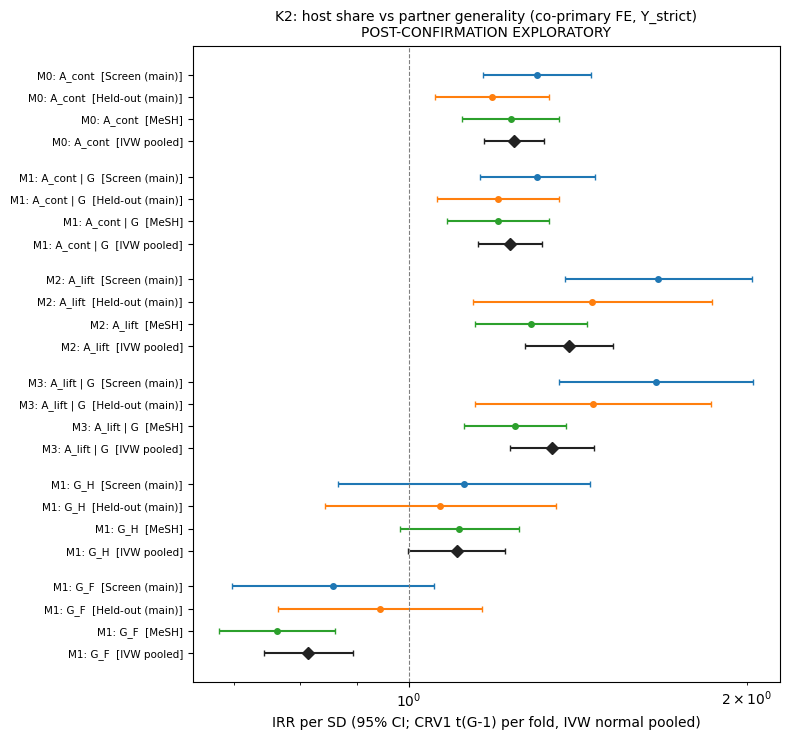

In [19]:
FNAME = {"screen": "Screen (main)", "heldout": "Held-out (main)", "mesh": "MeSH", "pooled": "IVW pooled"}
COL = {"screen": "#1f77b4", "heldout": "#ff7f0e", "mesh": "#2ca02c", "pooled": "#222222"}
rows_df = pd.DataFrame(rows)


def fig_forest(rows: pd.DataFrame) -> None:
    items = [("M0", "A_cont", "M0: A_cont"), ("M1", "A_cont", "M1: A_cont | G"), ("M2", "A_lift", "M2: A_lift"),
             ("M3", "A_lift", "M3: A_lift | G"), ("M1", "G_H", "M1: G_H"), ("M1", "G_F", "M1: G_F")]
    fig, ax = plt.subplots(figsize=(8, 7.5))
    yt, yl, y = [], [], 0
    for m, v, lab in items:
        for f in list(FOLDS) + ["pooled_IVW"]:
            r = rows[(rows.fold == f) & (rows.model == m) & (rows["var"] == v)]
            if not len(r):
                continue
            r = r.iloc[0]
            key = "pooled" if f == "pooled_IVW" else f
            ax.errorbar(r.irr_sd, y, xerr=[[r.irr_sd - r.irr_sd_lo], [r.irr_sd_hi - r.irr_sd]], fmt="D" if key ==
                        "pooled" else "o", color=COL[key], ms=6 if key == "pooled" else 4, capsize=2)
            yt.append(y)
            yl.append(f"{lab}  [{FNAME[key]}]")
            y -= 1
        y -= 0.6
    ax.axvline(1, color="grey", lw=0.8, ls="--")
    ax.set_xscale("log")
    ax.set_yticks(yt)
    ax.set_yticklabels(yl, fontsize=7.5)
    ax.set_xlabel("IRR per SD (95% CI; CRV1 t(G-1) per fold, IVW normal pooled)")
    ax.set_title("K2: host share vs partner generality (co-primary FE, Y_strict)\nPOST-CONFIRMATION EXPLORATORY",
                 fontsize=10)
    fig.tight_layout()
    plt.show()  # DEMO: saved to figures/F1_k2_forest.{png,pdf} in the original


fig_forest(rows_df[rows_df.row_type == "main"])

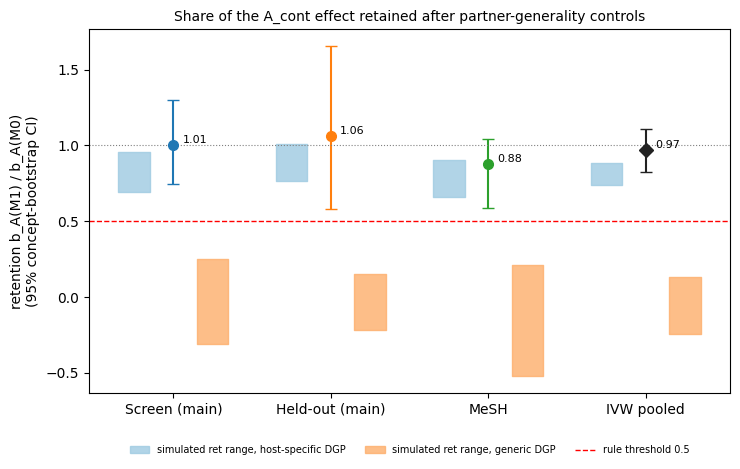

In [20]:
def fig_retention(summ: dict, power: dict) -> None:
    fig, ax = plt.subplots(figsize=(7.5, 4.8))
    keys = list(FOLDS) + ["pooled"]
    for i, k in enumerate(keys):
        d = summ["pooled"] if k == "pooled" else summ["folds"][k]
        pw = power["pooled"] if k == "pooled" else power["folds"][k]
        for dgp, off, c in (("DGP_S", -0.25, "#9ecae1"), ("DGP_G", 0.25, "#fdae6b")):
            q = (pw.get(dgp) or {}).get("ret_q025_q975")
            if q:
                ax.fill_between([i + off - 0.1, i + off + 0.1], q[0], q[1], color=c, alpha=0.8,
                                label=("simulated ret range, host-specific DGP" if dgp == "DGP_S" else
                                       "simulated ret range, generic DGP") if i == 0 else None)
        lo, hi = d["ret_ci"]
        # DEMO: yerr clipped at 0 (with fewer draws a point estimate can sit outside its percentile CI)
        ax.errorbar(i, d["ret"], yerr=[[max(d["ret"] - lo, 0)], [max(hi - d["ret"], 0)]], fmt="D" if k == "pooled" else "o",
                    color=COL[k], capsize=4, ms=7)
        ax.text(i + 0.06, d["ret"], f"{d['ret']:.2f}", fontsize=8, va="bottom")
    ax.axhline(0.5, color="red", ls="--", lw=1, label="rule threshold 0.5")
    ax.axhline(1.0, color="grey", ls=":", lw=0.8)
    ax.set_xticks(range(len(keys)))
    ax.set_xticklabels([FNAME[k] for k in keys])
    ax.set_ylabel("retention b_A(M1) / b_A(M0)\n(95% concept-bootstrap CI)")
    ax.set_title("Share of the A_cont effect retained after partner-generality controls", fontsize=10)
    ax.legend(fontsize=7, loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=3, frameon=False)
    fig.tight_layout()
    plt.show()  # DEMO: saved to figures/F2_retention.{png,pdf} in the original


fig_retention(summ, power)

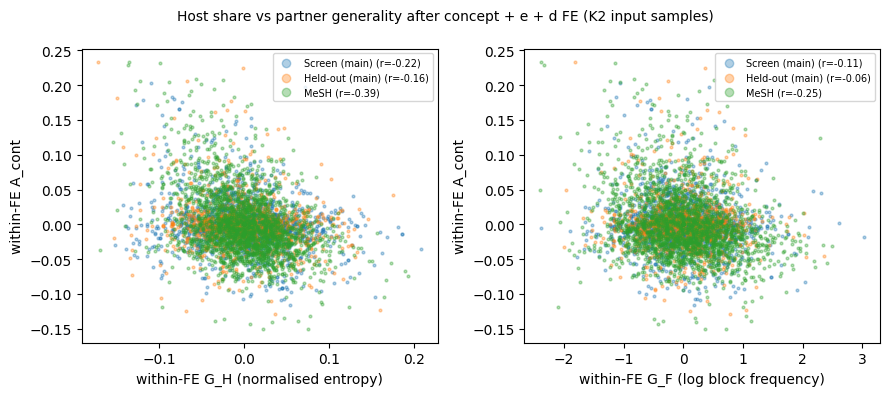

In [21]:
def fig_scatter(samples: dict) -> None:
    # DEMO: the original reads results/partner_generality.parquet; the K2 input samples hold the same rows
    fig, axs = plt.subplots(1, 2, figsize=(9, 4))
    for f in FOLDS:
        d = samples[f].dropna(subset=["A_cont", "G_H", "G_F"])
        M = within(d, ["A_cont", "G_H", "G_F"])
        for j, (ax, g) in enumerate(zip(axs, ("G_H", "G_F"))):
            r = np.corrcoef(M[:, 0], M[:, j + 1])[0, 1]
            ax.scatter(M[:, j + 1], M[:, 0], s=4, alpha=0.35, color=COL[f], label=f"{FNAME[f]} (r={r:.2f})")
    for ax, g in zip(axs, ("G_H (normalised entropy)", "G_F (log block frequency)")):
        ax.set_xlabel(f"within-FE {g}")
        ax.set_ylabel("within-FE A_cont")
        ax.legend(fontsize=7, markerscale=3)
    fig.suptitle("Host share vs partner generality after concept + e + d FE (K2 input samples)", fontsize=10)
    fig.tight_layout()
    plt.show()  # DEMO: saved to figures/F3_generality_scatter.{png,pdf} in the original


fig_scatter(samples)

## Demo vs full run

This table compares the demo against the recorded full run (`results/k2_summary.json` and `results/k2_rows.csv`). The point estimates and IRR CIs must match to numerical precision, because they use the same data and the same code. The retention CIs and randomisation p-values come from fewer draws, so they differ slightly.

In [22]:
ref_rows = pd.DataFrame(REF["k2_rows_main"])
cmp = []
for f in list(folds) + ["pooled_IVW"]:
    for m in MODELS:
        for v in MODELS[m]:
            if f == "pooled_IVW":
                x = summ["pooled"][f"{m}_{v}"]
                x = {"irr_sd": x["irr_sd"], "irr_sd_lo": x["irr_sd_lo"], "irr_sd_hi": x["irr_sd_hi"], "p_rand": None}
            else:
                x = fits[(f, m)][v]
            rr = ref_rows[(ref_rows.fold == f) & (ref_rows.model == m) & (ref_rows["var"] == v)].iloc[0]
            cmp.append({"fold": f, "model": m, "term": v, "IRR/SD demo": x["irr_sd"], "IRR/SD full": rr.irr_sd,
                        "CI demo": f"[{x['irr_sd_lo']:.3f}, {x['irr_sd_hi']:.3f}]",
                        "CI full": f"[{rr.irr_sd_lo:.3f}, {rr.irr_sd_hi:.3f}]",
                        "p_rand demo": x.get("p_rand"), "p_rand full": rr.p_rand})
cmp = pd.DataFrame(cmp)
max_d = float((np.log(cmp["IRR/SD demo"]) - np.log(cmp["IRR/SD full"])).abs().max())
print(cmp.to_string(index=False, float_format=lambda v: f"{v:.4g}"))
print(f"\nmax |ln IRR/SD demo - full| over all {len(cmp)} rows: {max_d:.1e}")

rt = []
for k in list(folds) + ["pooled"]:
    d = summ["pooled"] if k == "pooled" else summ["folds"][k]
    r_ = REF["summary_pooled"] if k == "pooled" else REF["summary_folds"][k]
    rt.append({"fold": k, "retention": d["ret"], "ret CI demo": f"[{d['ret_ci'][0]:.2f}, {d['ret_ci'][1]:.2f}]",
               "ret CI full": f"[{r_['ret_ci'][0]:.2f}, {r_['ret_ci'][1]:.2f}]", "ret full": r_["ret"],
               "verdict demo": d["verdict"], "verdict full": r_["verdict"]})
print()
print(pd.DataFrame(rt).to_string(index=False, float_format=lambda v: f"{v:.3f}"))
same = all(r["verdict demo"] == r["verdict full"] for r in rt)
print(f"\nverdicts identical to the full run: {same}")

      fold model   term  IRR/SD demo  IRR/SD full        CI demo        CI full  p_rand demo  p_rand full
    screen    M0 A_cont          1.3          1.3 [1.164, 1.452] [1.164, 1.452]     0.009901    0.0004998
    screen    M1 A_cont        1.302        1.302 [1.158, 1.464] [1.158, 1.464]     0.009901    0.0009995
    screen    M1    G_H        1.121        1.121 [0.866, 1.451] [0.866, 1.451]          NaN          NaN
    screen    M1    G_F       0.8562       0.8562 [0.696, 1.053] [0.696, 1.053]          NaN          NaN
    screen    M2 A_lift        1.668        1.668 [1.378, 2.019] [1.378, 2.019]     0.009901    0.0004998
    screen    M3 A_lift        1.661        1.661 [1.361, 2.026] [1.361, 2.026]     0.009901    0.0004998
    screen    M3    G_H        1.099        1.099 [0.866, 1.394] [0.866, 1.394]          NaN          NaN
    screen    M3    G_F       0.8446       0.8446 [0.691, 1.033] [0.691, 1.033]          NaN          NaN
   heldout    M0 A_cont        1.187        1.

## Reading

- **The frozen rule gives HOST-SPECIFIC in every fold and on the pool**, which is the pre-declared reading. Holding partner generality fixed removes almost none of the host-share effect: pooled retention is about 0.97, and its bootstrap CI lies well above the 0.5 threshold. `A_cont` keeps an IRR/SD of about 1.23 under M1.
- **The generic-accessibility story fails its own predictions:**
  - partner *frequency* lowers uptake (pooled `G_F` IRR/SD ≈ 0.81);
  - host share is *negatively* related to generality within FE;
  - the placebo host gains no signal under M1 (S10 PASS);
  - ADJACENT partners do not lose more than NATIVE ones (S3).
- **Caveats carried to the paper:**
  - K2 is post-confirmation and exploratory.
  - The `A_lift` leg is almost `ln A_cont` (r ≈ 0.997), so it mainly tests functional form, and its pooled estimate is heterogeneous (I² ≈ 0.72). The retention leg is the decisive one.
  - The held-out retention CI alone includes 0.5 in the full 1,000-draw run.
  - The pre-declared S2 row is partly mechanical. The post-hoc S2b keeps pooled `A_cont` ≈ 1.18.
  - Generality is observed only for profiled partners.
  - There is no pair-level conventionality measure.